In [1]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install openpyxl

In [3]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [4]:
#Loading the dataset
file_path = "../data/raw/default of credit card clients.xls"

df = pd.read_excel(file_path)

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [5]:
#Cheking the data 
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (30001, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 n

In [6]:
#Checking the data size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 30001
Number of columns: 25


In [7]:
#Inpecting the columns
df.columns.tolist()

['Unnamed: 0',
 'X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'X8',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'X19',
 'X20',
 'X21',
 'X22',
 'X23',
 'Y']

In [8]:
#checking data types and missing values
df.info()
print("Total missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

In [9]:
#inpecting summary statistics of the dataset
df.describe().T

,count,unique,top,freq
Unnamed: 0,30001,30001,30000,1
X1,30001,82,50000,3365
X2,30001,3,2,18112
X3,30001,8,2,14030
X4,30001,5,2,15964
X5,30001,57,29,1605
X6,30001,12,0,14737
X7,30001,12,0,15730
X8,30001,12,0,15764
X9,30001,12,0,16455


In [10]:
# Understanding the target variable
if "default payment next month" not in df.columns:
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)

df["default payment next month"].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [11]:
# Understanding the distribution of the target variable
df["default payment next month"].value_counts(normalize=True).mul(100).round(2)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

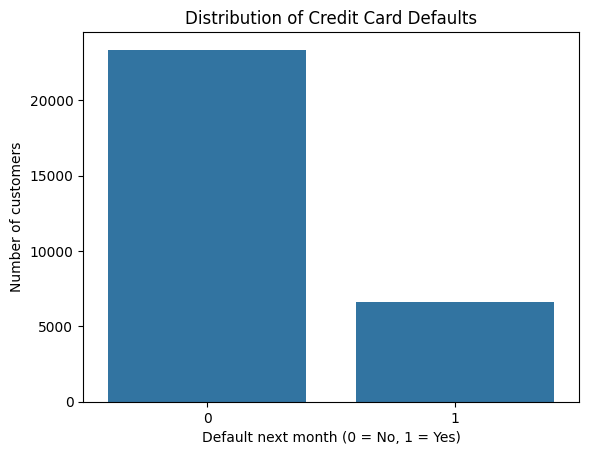

In [12]:
# Visualizing the distribution of the target variable
sns.countplot(data=df, x="default payment next month")
plt.title("Distribution of Credit Card Defaults")
plt.xlabel("Default next month (0 = No, 1 = Yes)")
plt.ylabel("Number of customers")
plt.show()

### Initial Finding: Target Variable Distribution

The dataset contains 30,000 customer records. Of these, 23,364 customers (77.88%) did not default on their next month's payment, while 6,636 customers (22.12%) defaulted.

The target variable is imbalanced because the non-default class is substantially larger than the default class. Consequently, model evaluation should include precision, recall, F1-score, and ROC-AUC alongside accuracy. Particular attention should be paid to recall for the default class, since failing to identify customers at risk of default can have financial consequences.


In [13]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Inspect the data types
print("\nColumn data types:")
print(df.dtypes)

Missing values per column:
0
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

Number of duplicate rows: 0

Column data types:
0
ID                            object
LIMIT_BAL                     object
SEX                           obj

In [14]:
# Check for duplicate rows and duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [15]:
#Inpecting the objects columns 
print(df[["PAY_AMT5", "default payment next month"]].head(10))

print("\nPAY_AMT5 types:")
print(df["PAY_AMT5"].map(type).value_counts())

print("\nTarget values:")
print(df["default payment next month"].value_counts(dropna=False).head(20))

0 PAY_AMT5 default payment next month
0        0                          1
1        0                          1
2     1000                          0
3     1069                          0
4      689                          0
5     1000                          0
6    13750                          0
7     1687                          0
8     1000                          0
9     1122                          0

PAY_AMT5 types:
PAY_AMT5
<class 'int'>    30000
Name: count, dtype: int64

Target values:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [16]:
# Inspecting data types on each column
print(df.dtypes.to_string())

0
ID                            object
LIMIT_BAL                     object
SEX                           object
EDUCATION                     object
MARRIAGE                      object
AGE                           object
PAY_0                         object
PAY_2                         object
PAY_3                         object
PAY_4                         object
PAY_5                         object
PAY_6                         object
BILL_AMT1                     object
BILL_AMT2                     object
BILL_AMT3                     object
BILL_AMT4                     object
BILL_AMT5                     object
BILL_AMT6                     object
PAY_AMT1                      object
PAY_AMT2                      object
PAY_AMT3                      object
PAY_AMT4                      object
PAY_AMT5                      object
PAY_AMT6                      object
default payment next month    object


In [17]:
#checking the target column unique values
print(df["default payment next month"].unique())

[1 0]


In [18]:
# Checking the first few rows of the dataset
print(df.head(3).to_string())

0 ID LIMIT_BAL SEX EDUCATION MARRIAGE AGE PAY_0 PAY_2 PAY_3 PAY_4 PAY_5 PAY_6 BILL_AMT1 BILL_AMT2 BILL_AMT3 BILL_AMT4 BILL_AMT5 BILL_AMT6 PAY_AMT1 PAY_AMT2 PAY_AMT3 PAY_AMT4 PAY_AMT5 PAY_AMT6 default payment next month
0  1     20000   2         2        1  24     2     2    -1    -1    -2    -2      3913      3102       689         0         0         0        0      689        0        0        0        0                          1
1  2    120000   2         2        2  26    -1     2     0     0     0     2      2682      1725      2682      3272      3455      3261        0     1000     1000     1000        0     2000                          1
2  3     90000   2         2        2  34     0     0     0     0     0     0     29239     14027     13559     14331     14948     15549     1518     1500     1000     1000     1000     5000                          0


In [19]:
# Checking column names
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [20]:
#checking the actual data types of the first 5 rows and first 5 columns
print(df.iloc[:5, :5].map(type))

0             ID      LIMIT_BAL            SEX      EDUCATION       MARRIAGE
0  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>
1  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>
2  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>
3  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>
4  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>  <class 'int'>


In [21]:
# Checking the first 10 values of specific columns
print(df["LIMIT_BAL"].head(10).tolist())
print(df["AGE"].head(10).tolist())
print(df["PAY_AMT5"].head(10).tolist())

[20000, 120000, 90000, 50000, 50000, 50000, 500000, 100000, 140000, 20000]
[24, 26, 34, 37, 57, 37, 29, 23, 28, 35]
[0, 0, 1000, 1069, 689, 1000, 13750, 1687, 1000, 1122]


In [22]:
# Inspecting the data types of all columns
print(df.dtypes.value_counts())
print("\nDataFrame type:", type(df))
print("Shape:", df.shape)

object    25
Name: count, dtype: int64

DataFrame type: <class 'pandas.core.frame.DataFrame'>
Shape: (30000, 25)


In [23]:
# Display the first few rows of the dataset
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [24]:
# Reading the raw data
raw_df = pd.read_excel(
    "../data/raw/default of credit card clients.xls",
    engine="xlrd",
    header=None
)

display(raw_df.head(5))
print("Raw shape:", raw_df.shape)
print("Raw types:")
print(raw_df.dtypes.value_counts())

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,NaN,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
3,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
4,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


Raw shape: (30002, 25)
Raw types:
object    25
Name: count, dtype: int64


In [25]:
# Displaying the first 3 rows of the raw data without index and header
display(raw_df.iloc[:3, :].to_string(index=False, header=False))

'NaN        X1  X2        X3       X4  X5    X6    X7    X8    X9   X10   X11       X12       X13       X14       X15       X16       X17      X18      X19      X20      X21      X22      X23                          Y\n ID LIMIT_BAL SEX EDUCATION MARRIAGE AGE PAY_0 PAY_2 PAY_3 PAY_4 PAY_5 PAY_6 BILL_AMT1 BILL_AMT2 BILL_AMT3 BILL_AMT4 BILL_AMT5 BILL_AMT6 PAY_AMT1 PAY_AMT2 PAY_AMT3 PAY_AMT4 PAY_AMT5 PAY_AMT6 default payment next month\n  1     20000   2         2        1  24     2     2    -1    -1    -2    -2      3913      3102       689         0         0         0        0      689        0        0        0        0                          1'

In [26]:
# Loading the dataset with the correct header row
df = pd.read_excel(
    "../data/raw/default of credit card clients.xls",
    engine="xlrd",
    header=1
)

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())

df.head()

Dataset shape: (30000, 25)

Data types:
int64    25
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [27]:
# Inspecting the first few rows of the dataset
print(df.dtypes.to_string())

print("\nTarget values:")
print(df["default payment next month"].value_counts())

print("\nMissing values:", df.isnull().sum().sum())

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64

Target values:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Missing 

In [28]:
# Inspecting the dataset
print("Dataset shape:", df.shape)

print("\nMissing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nTarget distribution:")
print(df["default payment next month"].value_counts())

Dataset shape: (30000, 25)

Missing values: 0
Duplicate rows: 0

Column data types:
int64    25
Name: count, dtype: int64

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [29]:
# Analyzing the distribution of LIMIT_BAL across default payment categories
df.groupby("default payment next month")["LIMIT_BAL"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
default payment next month,,,,,
0,23364,178099.73,150000.0,10000,1000000
1,6636,130109.66,90000.0,10000,740000


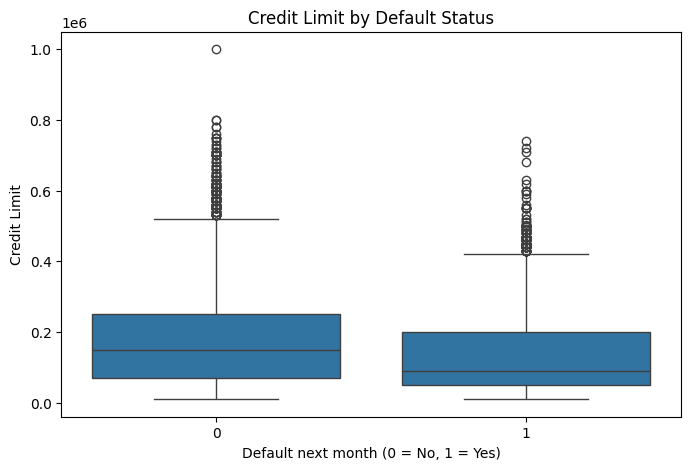

In [30]:
# Visualizing the distribution of LIMIT_BAL across default payment categories
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="default payment next month",
    y="LIMIT_BAL"
)

plt.title("Credit Limit by Default Status")
plt.xlabel("Default next month (0 = No, 1 = Yes)")
plt.ylabel("Credit Limit")
plt.show()

### Finding 1: Credit Limit and Default Risk

The initial analysis suggests a potential negative association between credit limit and default status. Customers who did not default appear to have higher credit limits overall, while customers who defaulted may have lower credit limits.

However, the distributions overlap, and some customers in the non-default group have particularly high credit limits. Therefore, credit limit alone cannot reliably determine whether a customer will default.

This finding is exploratory rather than conclusive. Further statistical analysis is needed to assess the strength and significance of the association, while accounting for other factors such as repayment history, age, and previous payment amounts.


In [31]:
#Comparing default rates across different payment statuses
default_rates = (
    df.groupby("PAY_0")["default payment next month"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate"})
)

default_rates["default_rate"] *= 100

print(default_rates.round(2))

       default_rate  count
PAY_0                     
-2            13.23   2759
-1            16.78   5686
 0            12.81  14737
 1            33.95   3688
 2            69.14   2667
 3            75.78    322
 4            68.42     76
 5            50.00     26
 6            54.55     11
 7            77.78      9
 8            57.89     19


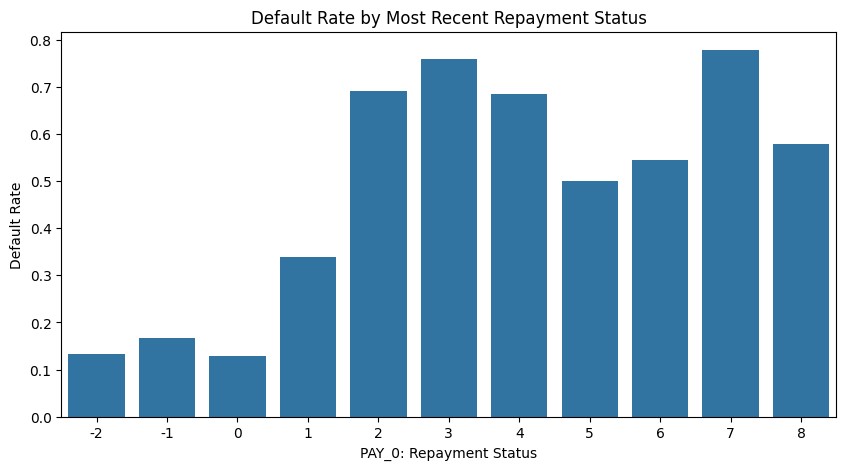

In [32]:
#visualizing the default rates across different payment statuses
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="PAY_0",
    y="default payment next month",
    errorbar=None
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0: Repayment Status")
plt.ylabel("Default Rate")
plt.show()

In [33]:
# Performing Chi-square test for independence between PAY_0 and default payment next month
#null hypothesis: There is no association between PAY_0 and default payment next month
#alternative hypothesis: There is an association between PAY_0 and default payment next month
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["PAY_0"],
    df["default payment next month"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2, 2))
print("Degrees of freedom:", dof)
print("P-value:", p_value)

Chi-square statistic: 5365.96
Degrees of freedom: 10
P-value: 0.0


### Statistical Finding: Repayment Status and Default

A chi-square test of independence was conducted to investigate the association between the most recent repayment status (`PAY_0`) and next-month default.

The test produced a chi-square statistic of 5,365.96 with 10 degrees of freedom. The p-value was reported as 0.0 by the software, indicating that it was below the numerical precision displayed.

At the 5% significance level, the null hypothesis of independence was rejected. The results provide strong evidence of an association between repayment status and next-month default. Repayment history will therefore be investigated as a potentially useful predictor in the machine-learning stage.

This is an observational finding and does not establish causation.


In [34]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Separate features and target
X = df.drop(
    columns=["default payment next month", "ID"]
)

y = df["default payment next month"]

# Split before fitting the model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 24000
Testing records: 6000


In [35]:
# Building a pipeline for scaling and logistic regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8077
ROC-AUC: 0.7076

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

Confusion Matrix:
[[4528  145]
 [1009  318]]


### Baseline Logistic Regression Model Evaluation

The baseline logistic regression model achieved an accuracy of 80.77% and a ROC-AUC score of 0.7076 on the test dataset. Although the model correctly classified most customers who did not default, its recall for the default class was approximately 23.96%. This means that it identified only 318 of the 1,327 customers who actually defaulted.

The confusion matrix revealed 1,009 false negatives, indicating that the model missed a substantial proportion of actual defaults. Therefore, accuracy alone does not adequately represent the model's usefulness for credit-risk prediction. Further experimentation should focus on improving default detection while considering the trade-off between missed defaults and incorrectly flagged customers.


In [36]:
#comparing the logistic regression model with a simple baseline model using DummyClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

print("Dummy accuracy:", round(accuracy_score(y_test, dummy_pred), 4))
print("Dummy default recall:", round(recall_score(y_test, dummy_pred), 4))

Dummy accuracy: 0.7788
Dummy default recall: 0.0


### Improving Default Detection Through Threshold Tuning

In [37]:
#improving default detection through threshold tuning and evaluating the model's performance using different metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score
)

# Test different probability thresholds
thresholds = [0.50, 0.40, 0.30, 0.20]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Default recall:", round(
        recall_score(y_test, y_pred_threshold), 4
    ))
    print("Default precision:", round(
        precision_score(y_test, y_pred_threshold), 4
    ))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))


Threshold: 0.5
Default recall: 0.2396
Default precision: 0.6868
Confusion matrix:
[[4528  145]
 [1009  318]]

Threshold: 0.4
Default recall: 0.3806
Default precision: 0.6344
Confusion matrix:
[[4382  291]
 [ 822  505]]

Threshold: 0.3
Default recall: 0.4589
Default precision: 0.5546
Confusion matrix:
[[4184  489]
 [ 718  609]]

Threshold: 0.2
Default recall: 0.679
Default precision: 0.3187
Confusion matrix:
[[2747 1926]
 [ 426  901]]


Threshold 0.50: Few false alarms, but the model misses most actual defaults.

Threshold 0.40: Detects more defaults, with a moderate increase in false alarms.

Threshold 0.30: A further improvement in default detection, but nearly half of the customers flagged as defaulters are false alarms.

Threshold 0.20: Detects 901 of 1,327 actual defaults, but incorrectly flags 1,926 customers who did not default.

In [38]:
# Evaluating model performance at different thresholds

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.50, 0.40, 0.30, 0.20]:
    predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.5,0.6868,0.2396,0.3553
1,0.4,0.6344,0.3806,0.4757
2,0.3,0.5546,0.4589,0.5023
3,0.2,0.3187,0.6790,0.4338


### Decision Threshold Evaluation

The logistic regression model was evaluated at probability thresholds of 0.50, 0.40, 0.30, and 0.20. Lowering the threshold increased recall for the default class but generally reduced precision, demonstrating the trade-off between detecting more potential defaulters and generating more false positives.

The threshold of 0.30 achieved the highest F1-score of 0.5023 among the four tested thresholds. At this threshold, precision was 0.5546 and recall was 0.4589. In comparison, the threshold of 0.20 achieved a higher recall of 0.6790 but a lower F1-score of 0.4338.

Therefore, 0.30 is a promising candidate for further evaluation. The final threshold should be selected using validation data and business cost considerations rather than F1-score alone.


In [39]:
#We're using class_weight="balanced" to give the minority default class more influence during training, and limiting the tree to five levels to help control overfitting.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, tree_pred), 4))

print("Decision Tree ROC-AUC:",
      round(roc_auc_score(y_test, tree_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.7708
Decision Tree ROC-AUC: 0.7571

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.68      6000
weighted avg       0.78      0.77      0.78      6000



### Decision Tree Model Evaluation

The Decision Tree classifier achieved an accuracy of 77.08% and a ROC-AUC score of 0.7571. Its recall for the default class was approximately 55%, with a precision of 48% and an F1-score of 0.52.

Compared with the baseline logistic regression model, the Decision Tree achieved a higher ROC-AUC and substantially improved default detection, although its overall accuracy was lower. This suggests that the Decision Tree may be more useful for identifying potential defaulters when detecting defaults is an important objective.

However, the model also produces more false-positive predictions. Further evaluation and model tuning are necessary before selecting a final model for credit-risk analysis.


In [40]:
#trying a Random Forest model to see if it improves performance over the Decision Tree model. Random Forests are an ensemble method that combines multiple decision trees to improve predictive accuracy and control overfitting.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred), 4))

print("Random Forest ROC-AUC:",
      round(roc_auc_score(y_test, rf_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.783
Random Forest ROC-AUC: 0.7758

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000



### Random Forest Model Evaluation

The Random Forest classifier achieved an accuracy of 78.30% and a ROC-AUC score of 0.7758. Its precision for the default class was approximately 51%, with a recall of 59% and an F1-score of 0.54.

Among the three models evaluated so far, Random Forest achieved the highest ROC-AUC and the strongest default-class recall and F1-score at their current prediction rules. These results suggest that it is a promising candidate for identifying customers at risk of default.

Nevertheless, approximately 41% of actual defaults were still missed. The model also produced false-positive predictions, so further validation, threshold analysis, and consideration of business costs are required before making a final model recommendation.


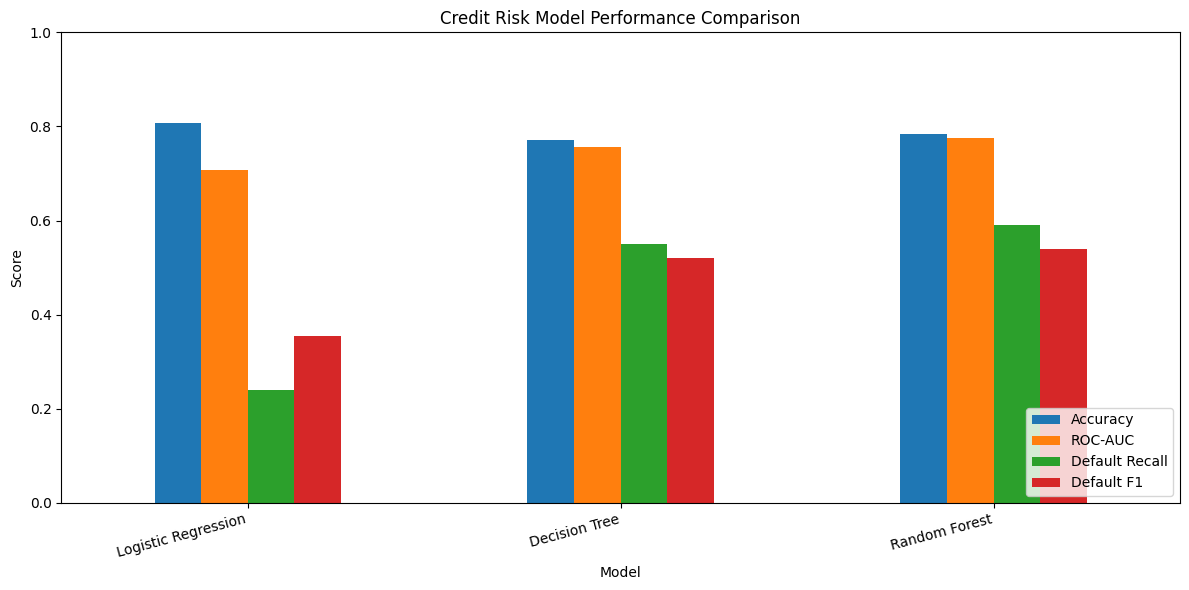

In [41]:
#creating a visualisation to compare the performance of the Logistic Regression, Decision Tree, and Random Forest models using accuracy, ROC-AUC, default recall, and default F1 score as metrics.
import pandas as pd
import matplotlib.pyplot as plt

# Creating a DataFrame to hold the performance metrics for each model
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [0.8077, 0.7708, 0.7830],
    "ROC-AUC": [0.7076, 0.7571, 0.7758],
    "Default Recall": [0.2396, 0.55, 0.59],
    "Default F1": [0.3553, 0.52, 0.54]
})

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Credit Risk Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [42]:
# Visualizing Feature Importance
#highest importance features from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,PAY_0,0.266908
6,PAY_2,0.099770
8,PAY_4,0.065762
7,PAY_3,0.058079
0,LIMIT_BAL,0.050315
10,PAY_6,0.045898
18,PAY_AMT2,0.041053
17,PAY_AMT1,0.040763
9,PAY_5,0.035083
11,BILL_AMT1,0.035023


1. PAY_0 is the strongest predictor.

It contributes approximately 26.69% of the Random Forest's total impurity-based feature importance. This variable represents the most recent repayment status in the dataset. Its prominence suggests recent repayment behaviour is highly useful for distinguishing between customers who default and those who do not.

2. Repayment history dominates the top features.

PAY_2, PAY_3, PAY_4, PAY_5, and PAY_6 represent repayment status across other recent periods. Their presence suggests that repayment behaviour over time is important to the model.

3. Credit limits and payment amounts also matter.

LIMIT_BAL, PAY_AMT1, and PAY_AMT2 appear among the top predictors, along with BILL_AMT1. These variables capture information about credit limits, payments, and billed amounts.

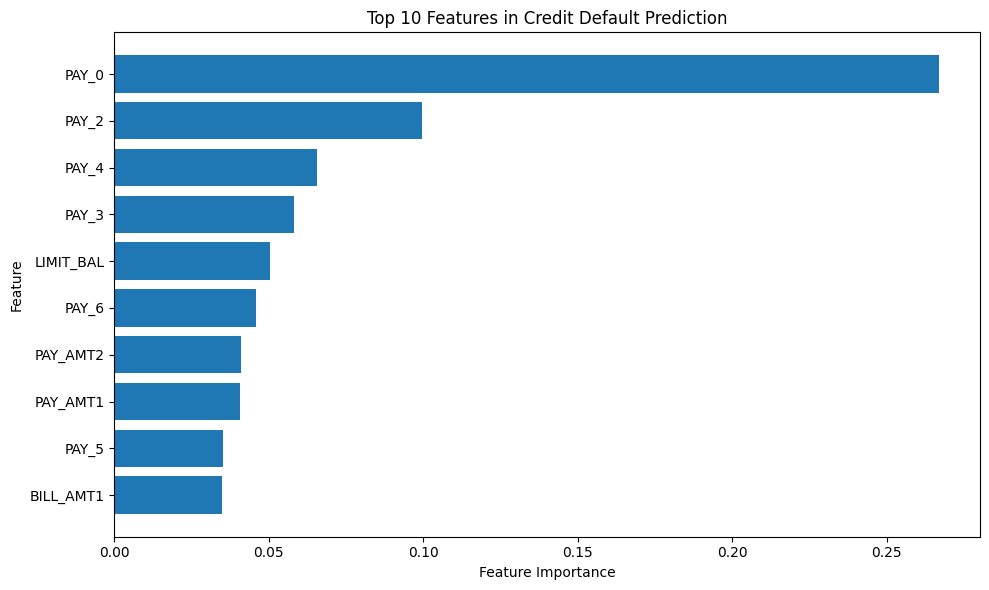

In [43]:
#plotting the top 10 features based on their importance in the Random Forest model
#This displays important features from bottom to top, with the strongest predictor at the top.
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features in Credit Default Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

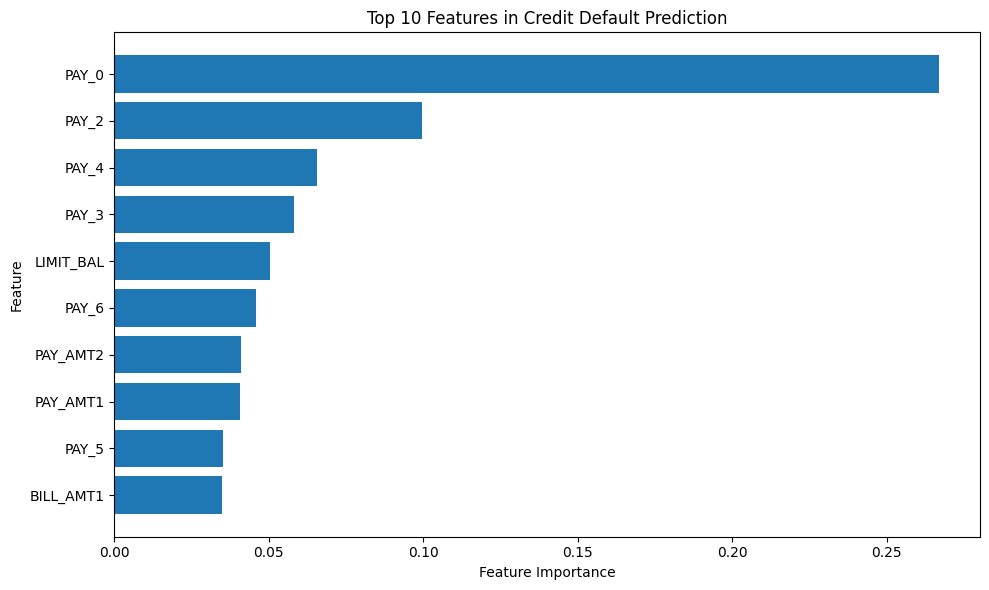

In [44]:
# Saving the feature importance plot to a file
from pathlib import Path

output_dir = Path("../reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features in Credit Default Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    output_dir / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

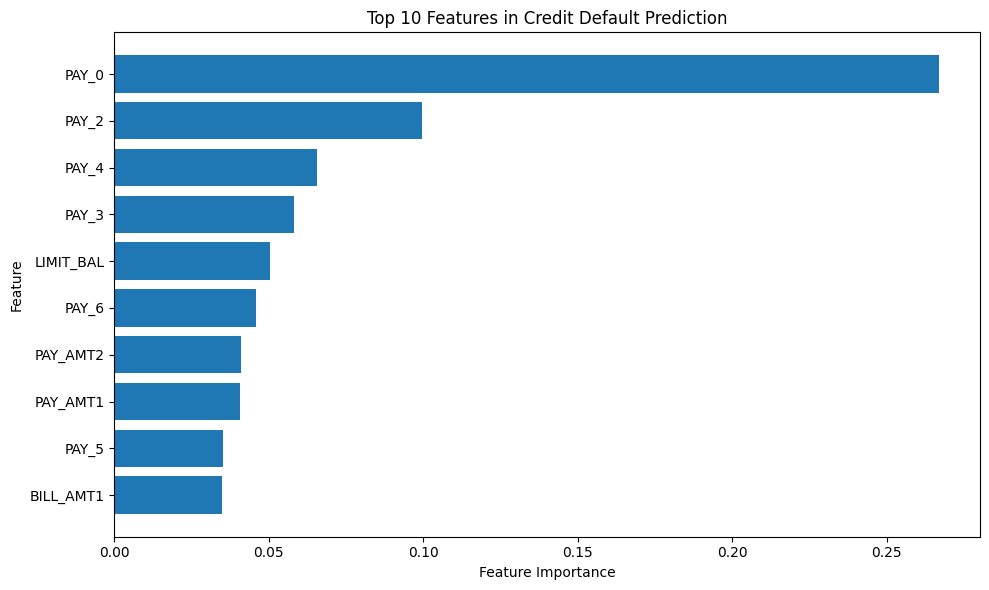

Chart saved to: ..\reports\figures\feature_importance.png


In [45]:
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("../reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features in Credit Default Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    output_dir / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", output_dir / "feature_importance.png")

In [46]:
# Checking if the feature importance chart was saved successfully
chart_path = Path("../reports/figures/feature_importance.png")

print("File exists:", chart_path.exists())
print("File size (bytes):", chart_path.stat().st_size if chart_path.exists() else 0)

File exists: True
File size (bytes): 98505


In [47]:
# Performing cross-validation on the Random Forest model to assess its performance and stability across different subsets of the training data
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
# Setting up Stratified K-Fold cross-validation to maintain the proportion of classes in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# Performing cross-validation and collecting results for various metrics
cv_results = cross_validate(
    rf_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ],
    "Std Dev": [
        cv_results["test_accuracy"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std()
    ]
})
# Displaying the cross-validation summary
cv_summary.round(4)

,Metric,Mean,Std Dev
0,Accuracy,0.7832,0.0024
1,ROC-AUC,0.7818,0.0052
2,Precision,0.5088,0.0047
3,Recall,0.5834,0.0073
4,F1 Score,0.5435,0.0045


### Random Forest Cross-Validation

The Random Forest classifier was evaluated using five-fold stratified cross-validation on the training dataset. The model achieved a mean accuracy of 0.7832 and a mean ROC-AUC of 0.7818. The mean precision, recall, and F1-score were 0.5088, 0.5834, and 0.5435, respectively.

The relatively small standard deviations across the five folds suggest that model performance was reasonably consistent across the validation splits. However, the recall result indicates that the model still fails to identify a considerable proportion of actual defaults at its default classification threshold.

These findings support further evaluation of the Random Forest, including threshold selection based on business costs and final testing on the held-out test dataset.


In [48]:
# Displaying dataset information
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining default rate:")
print(y_train.mean().round(4))

print("\nTesting default rate:")
print(y_test.mean().round(4))

Training set: (24000, 23)
Testing set: (6000, 23)

Training default rate:
0.2212

Testing default rate:
0.2212


FINAL RANDOM FOREST TEST RESULTS
--------------------------------
Accuracy: 0.783
Precision: 0.5082
Recall: 0.5855
F1-score: 0.5441
ROC-AUC: 0.7758

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000



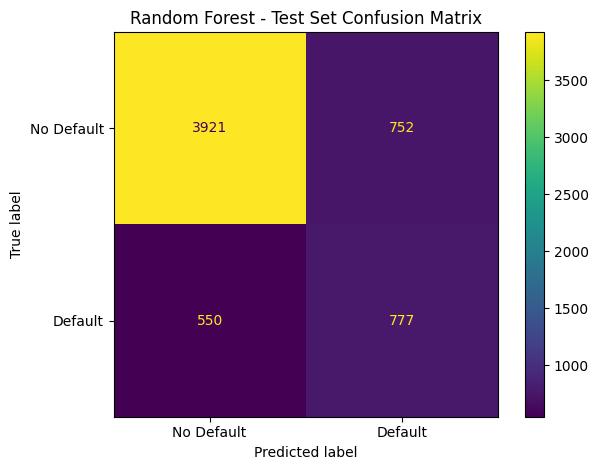

In [49]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions on the held-out test set
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Summary metrics
print("FINAL RANDOM FOREST TEST RESULTS")
print("--------------------------------")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1-score:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion matrix visualization
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Default", "Default"]
)
plt.title("Random Forest - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

### Business Interpretation of the Random Forest Model

The Random Forest model correctly identified 777 of the 1,327 customers who defaulted, while missing 550 actual defaults. Its ability to detect potential defaulters is useful, but the missed cases show that the model cannot independently determine creditworthiness.

The model also flagged 752 customers who did not default. If these predictions were used to automatically reject loan applicants, some creditworthy customers could be unfairly excluded. A more appropriate application would be to use the predictions as one input in a broader credit assessment and review process.

The results illustrate a trade-off between identifying customers at risk of default and minimizing false-positive predictions. The final model and decision threshold should be selected using validation data, the financial costs of prediction errors, and appropriate fairness and regulatory considerations.


In [50]:
# Hypothetical costs per prediction error
cost_per_missed_default = 20000
cost_per_false_positive = 2000

# From your confusion matrix:
false_negatives = 550
false_positives = 752

missed_default_cost = (
    false_negatives * cost_per_missed_default
)

false_positive_cost = (
    false_positives * cost_per_false_positive
)

total_error_cost = (
    missed_default_cost + false_positive_cost
)

print("Cost of missed defaults: KSh",
      f"{missed_default_cost:,.0f}")

print("Cost of false positives: KSh",
      f"{false_positive_cost:,.0f}")

print("Total estimated error cost: KSh",
      f"{total_error_cost:,.0f}")

Cost of missed defaults: KSh 11,000,000
Cost of false positives: KSh 1,504,000
Total estimated error cost: KSh 12,504,000


In [51]:
# Evaluating the cost implications of different probability thresholds for the Random Forest model
import pandas as pd
from sklearn.metrics import confusion_matrix

cost_per_missed_default = 20000
cost_per_false_positive = 2000

cost_results = []

for threshold in [0.50, 0.40, 0.30, 0.20]:
    predictions = (rf_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions
    ).ravel()

    missed_cost = fn * cost_per_missed_default
    false_positive_cost = fp * cost_per_false_positive

    cost_results.append({
        "Threshold": threshold,
        "True Positives": tp,
        "Missed Defaults": fn,
        "False Positives": fp,
        "Missed Default Cost": missed_cost,
        "False Positive Cost": false_positive_cost,
        "Total Error Cost": missed_cost + false_positive_cost
    })

cost_df = pd.DataFrame(cost_results)

cost_df

,Threshold,True Positives,Missed Defaults,False Positives,Missed Default Cost,False Positive Cost,Total Error Cost
0,0.5,777,550,752,11000000,1504000,12504000
1,0.4,925,402,1399,8040000,2798000,10838000
2,0.3,1158,169,2696,3380000,5392000,8772000
3,0.2,1304,23,4149,460000,8298000,8758000


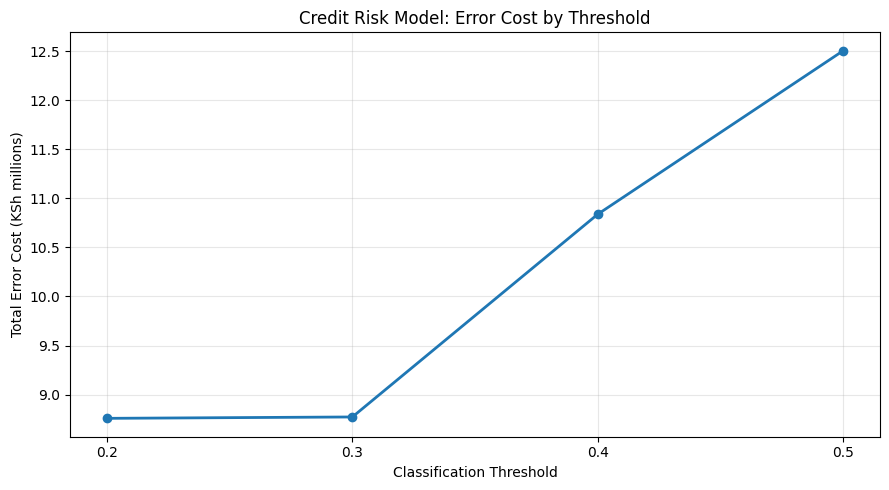

In [52]:

#creating a visualisation to compare the total error costs at different probability thresholds for the Random Forest model. This will help in understanding how adjusting the threshold affects the financial implications of prediction errors.
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    cost_df["Threshold"],
    cost_df["Total Error Cost"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.xlabel("Classification Threshold")
plt.ylabel("Total Error Cost (KSh millions)")
plt.title("Credit Risk Model: Error Cost by Threshold")
plt.xticks(cost_df["Threshold"])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../reports/figures/threshold_cost_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Cost Analysis and Threshold Selection

A cost-sensitive evaluation was conducted to assess the Random Forest credit-risk model under different classification thresholds. For this analysis, a missed default was assigned a hypothetical cost of KSh 20,000, while a false positive was assigned a cost of KSh 2,000.

The total estimated error cost decreased from KSh 12,504,000 at a threshold of 0.50 to KSh 8,772,000 at 0.30. At a threshold of 0.20, the estimated cost decreased further to KSh 8,758,000, the lowest among the four thresholds tested. However, this threshold also produced 4,149 false positives, compared with 2,696 at 0.30.

Although 0.20 minimized the estimated error cost under the stated assumptions, the difference between the 0.20 and 0.30 thresholds was only KSh 14,000. Therefore, threshold selection should consider operational workload, customer impact, and the reliability of the assumed costs, rather than total error cost alone. These estimates are illustrative and do not represent actual losses for a financial institution.


In [53]:
#comparing the performance of the Logistic Regression, Decision Tree, and Random Forest models using accuracy, ROC-AUC, default recall, and default F1 score as metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Predictions from each model
model_results = []

models = {
    "Logistic Regression": (y_pred, y_prob),
    "Decision Tree": (tree_pred, tree_model.predict_proba(X_test)[:, 1]),
    "Random Forest": (rf_pred, rf_prob)
}

for model_name, (predictions, probabilities) in models.items():
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

comparison_df = pd.DataFrame(model_results)
comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.808,0.687,0.240,0.355,0.708
1,Decision Tree,0.771,0.484,0.552,0.516,0.757
2,Random Forest,0.783,0.508,0.586,0.544,0.776


### Comparative Model Evaluation

Three classification models were evaluated on the same stratified test set: Logistic Regression, Decision Tree, and Random Forest.

Logistic Regression achieved the highest accuracy of 80.8%, but its default recall was only 24.0%, indicating that it missed a substantial proportion of customers who defaulted. The Decision Tree achieved a recall of 55.2% and an ROC-AUC of 0.757. Random Forest performed best in terms of recall (58.6%), F1-score (0.544), and ROC-AUC (0.776).

These findings suggest that Random Forest is the strongest candidate among the three models for further development in this project. However, the final model and classification threshold should be selected using validation results, business costs, interpretability requirements, and fairness considerations. The test set should be reserved for the final evaluation rather than repeatedly used to tune the model.


In [54]:
# Installing the SHAP library for explainability
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [55]:
#importing the SHAP library to analyze feature importance and model interpretability
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [56]:
# Creating a visualisation to compare the total error costs at different probability thresholds for the Random Forest model. This will help in understanding how adjusting the threshold affects the financial implications of prediction errors.
import shap
import pandas as pd

# Use a sample of the test data to keep the analysis manageable
X_explain = X_test.sample(n=500, random_state=42)

# Create an explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_explain)

print("SHAP analysis completed!")
print("Sample size:", X_explain.shape)

SHAP analysis completed!
Sample size: (500, 23)


In [57]:
# Analyzing SHAP values
print("SHAP output type:", type(shap_values))
print("SHAP output shape:", getattr(shap_values, "shape", "No direct shape"))

SHAP output type: <class 'numpy.ndarray'>
SHAP output shape: (500, 23, 2)


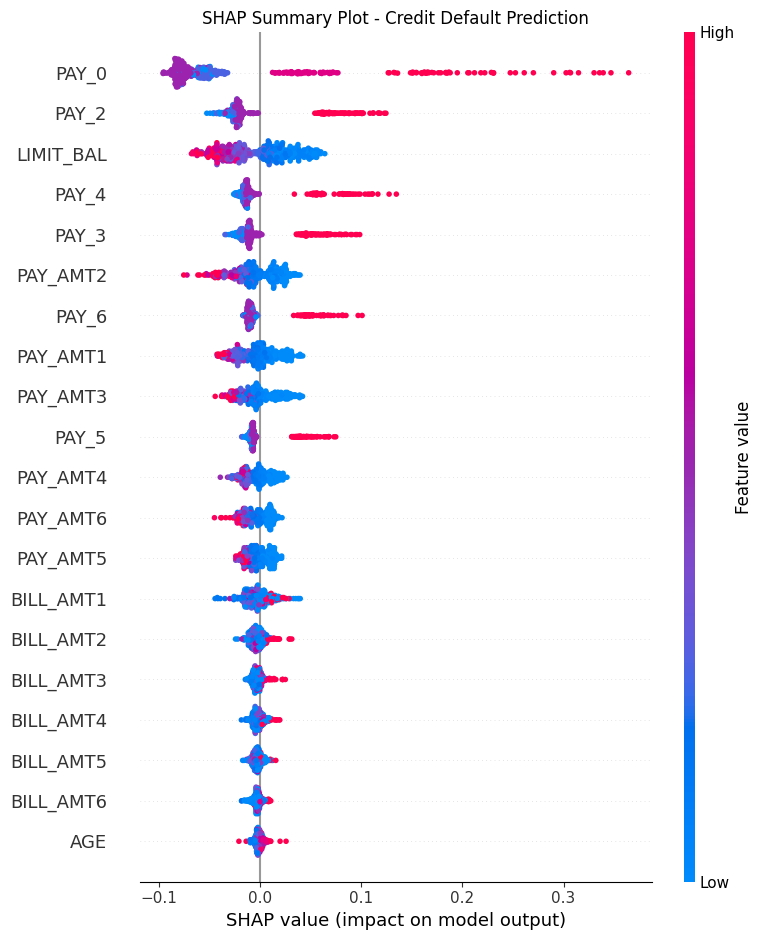

In [58]:
#creating a SHAP summary plot to visualize the impact of features on the model's predictions, focusing on the default class (class 1).
import matplotlib.pyplot as plt
import shap

# Select SHAP values for class 1 (default)
shap_default = shap_values[:, :, 1]

# Create the SHAP summary plot
shap.summary_plot(
    shap_default,
    X_explain,
    show=False
)

plt.title("SHAP Summary Plot - Credit Default Prediction")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../reports/figures/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
# Analyzing SHAP values
shap_importance = pd.DataFrame({
    "Feature": X_explain.columns,
    "Mean_Absolute_SHAP": abs(shap_default).mean(axis=0)
})
# Sorting features by their mean absolute SHAP values to identify the most influential features in the model's predictions
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)
# Displaying the top 10 features based on their mean absolute SHAP values
shap_importance.head(10)

,Feature,Mean_Absolute_SHAP
5,PAY_0,0.080479
6,PAY_2,0.032828
0,LIMIT_BAL,0.028425
8,PAY_4,0.022605
7,PAY_3,0.021486
18,PAY_AMT2,0.017761
10,PAY_6,0.015596
17,PAY_AMT1,0.015228
19,PAY_AMT3,0.014508
9,PAY_5,0.012945


In [60]:

# Prepare the Random Forest importance table
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "RF_Importance": rf_model.feature_importances_
})

# Merge both importance methods
importance_comparison = shap_importance.merge(
    rf_importance,
    on="Feature",
    how="inner"
)

# Rank features under each method
importance_comparison["SHAP_Rank"] = (
    importance_comparison["Mean_Absolute_SHAP"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_comparison["RF_Rank"] = (
    importance_comparison["RF_Importance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_comparison = importance_comparison.sort_values(
    "SHAP_Rank"
)

importance_comparison.head(10).round(4)

,Feature,Mean_Absolute_SHAP,RF_Importance,SHAP_Rank,RF_Rank
0,PAY_0,0.0805,0.2669,1,1
1,PAY_2,0.0328,0.0998,2,2
2,LIMIT_BAL,0.0284,0.0503,3,5
3,PAY_4,0.0226,0.0658,4,3
4,PAY_3,0.0215,0.0581,5,4
5,PAY_AMT2,0.0178,0.0411,6,7
6,PAY_6,0.0156,0.0459,7,6
7,PAY_AMT1,0.0152,0.0408,8,8
8,PAY_AMT3,0.0145,0.0341,9,11
9,PAY_5,0.0129,0.0351,10,9


In [61]:

# Save the comparison table
importance_comparison.to_csv(
    "../reports/shap_feature_importance_comparison.csv",
    index=False
)

print("Feature importance comparison saved successfully!")

# Verify that the file exists
from pathlib import Path

file_path = Path(
    "../reports/shap_feature_importance_comparison.csv"
)

print("File exists:", file_path.exists())
print("Saved to:", file_path.resolve())

Feature importance comparison saved successfully!
File exists: True
Saved to: C:\Users\Administrator\OneDrive\Desktop\Credit_Risk_Prediction\reports\shap_feature_importance_comparison.csv


### Model Explainability Using SHAP

SHAP (SHapley Additive exPlanations) was used to interpret the Random Forest credit-default prediction model. Explanations were calculated for a sample of 500 customers from the test dataset, using 23 input features.

The analysis identified PAY_0 as the most influential feature, followed by PAY_2 and LIMIT_BAL. PAY_4, PAY_3 and several payment-amount variables also contributed to the model's predictions. These results suggest that repayment-status information and credit-related financial variables play important roles in the fitted model.

The SHAP ranking was compared with the Random Forest's impurity-based feature importance. Both methods ranked PAY_0 and PAY_2 first and second, respectively. However, some features had different rankings across the two methods, illustrating that feature importance depends partly on the explanation technique used.

These findings describe the behavior of the fitted model rather than causal relationships. Further analysis is required to understand the direction of individual feature effects, assess model stability, and evaluate fairness before considering real-world lending applications.
